# Uber/Lyft Dynamic Pricing Prediction

This notebook explores the Uber & Lyft Boston dataset and builds a machine learning model to predict ride prices.

The workflow includes:
- Data cleaning
- Exploratory Data Analysis (EDA)
- Feature engineering
- Model training
- Hyperparameter tuning

## 1.Imports

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import shap

# Modeling & Evaluation
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Global Configurations
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_SEED = 42

## 2. Load the Dataset

In [45]:
df = pd.read_csv('rideshare_kaggle.csv')

print(f"Dataset Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print("\nMissing Values Per Column (Top 5):")
print(df.isnull().sum().sort_values(ascending=False).head(5))

Dataset Shape: 693,071 rows, 57 columns

Missing Values Per Column (Top 5):
price                      55095
id                             0
ozone                          0
temperatureLowTime             0
apparentTemperatureHigh        0
dtype: int64


In [46]:
df.head()

,id,timestamp,hour,day,month,datetime,timezone,source,destination,cab_type,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,1.544953e+09,9,16,12,2018-12-16 09:30:07,America/New_York,Haymarket Square,North Station,Lyft,...,0.1276,1544979600,39.89,1545012000,43.68,1544968800,33.73,1545012000,38.07,1544958000
1,4bd23055-6827-41c6-b23b-3c491f24e74d,1.543284e+09,2,27,11,2018-11-27 02:00:23,America/New_York,Haymarket Square,North Station,Lyft,...,0.1300,1543251600,40.49,1543233600,47.30,1543251600,36.20,1543291200,43.92,1543251600
2,981a3613-77af-4620-a42a-0c0866077d1e,1.543367e+09,1,28,11,2018-11-28 01:00:22,America/New_York,Haymarket Square,North Station,Lyft,...,0.1064,1543338000,35.36,1543377600,47.55,1543320000,31.04,1543377600,44.12,1543320000
3,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,1.543554e+09,4,30,11,2018-11-30 04:53:02,America/New_York,Haymarket Square,North Station,Lyft,...,0.0000,1543507200,34.67,1543550400,45.03,1543510800,30.30,1543550400,38.53,1543510800
4,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,1.543463e+09,3,29,11,2018-11-29 03:49:20,America/New_York,Haymarket Square,North Station,Lyft,...,0.0001,1543420800,33.10,1543402800,42.18,1543420800,29.11,1543392000,35.75,1543420800


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           693071 non-null  object 
 1   timestamp                    693071 non-null  float64
 2   hour                         693071 non-null  int64  
 3   day                          693071 non-null  int64  
 4   month                        693071 non-null  int64  
 5   datetime                     693071 non-null  object 
 6   timezone                     693071 non-null  object 
 7   source                       693071 non-null  object 
 8   destination                  693071 non-null  object 
 9   cab_type                     693071 non-null  object 
 10  product_id                   693071 non-null  object 
 11  name                         693071 non-null  object 
 12  price                        637976 non-null  float64
 13 

In [48]:
df.describe()

,timestamp,hour,day,month,price,distance,surge_multiplier,latitude,longitude,temperature,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
count,6.930710e+05,693071.000000,693071.000000,693071.000000,637976.000000,693071.000000,693071.000000,693071.000000,693071.000000,693071.000000,...,693071.000000,6.930710e+05,693071.000000,6.930710e+05,693071.000000,6.930710e+05,693071.000000,6.930710e+05,693071.000000,6.930710e+05
mean,1.544046e+09,11.619137,17.794365,11.586684,16.545125,2.189430,1.013870,42.338172,-71.066151,39.584388,...,0.037374,1.544044e+09,33.457774,1.544042e+09,45.261313,1.544047e+09,29.731002,1.544048e+09,41.997343,1.544048e+09
std,6.891925e+05,6.948114,9.982286,0.492429,9.324359,1.138937,0.091641,0.047840,0.020302,6.726084,...,0.055214,6.912028e+05,6.467224,6.901954e+05,5.645046,6.901353e+05,7.110494,6.871862e+05,6.936841,6.910777e+05
min,1.543204e+09,0.000000,1.000000,11.000000,2.500000,0.020000,1.000000,42.214800,-71.105400,18.910000,...,0.000000,1.543162e+09,15.630000,1.543122e+09,33.510000,1.543154e+09,11.810000,1.543136e+09,28.950000,1.543187e+09
25%,1.543444e+09,6.000000,13.000000,11.000000,9.000000,1.280000,1.000000,42.350300,-71.081000,36.450000,...,0.000000,1.543421e+09,30.170000,1.543399e+09,42.570000,1.543439e+09,27.760000,1.543399e+09,36.570000,1.543439e+09
50%,1.543737e+09,12.000000,17.000000,12.000000,13.500000,2.160000,1.000000,42.351900,-71.063100,40.490000,...,0.000400,1.543770e+09,34.240000,1.543727e+09,44.680000,1.543788e+09,30.130000,1.543745e+09,40.950000,1.543788e+09
75%,1.544828e+09,18.000000,28.000000,12.000000,22.500000,2.920000,1.000000,42.364700,-71.054200,43.580000,...,0.091600,1.544807e+09,38.880000,1.544789e+09,46.910000,1.544814e+09,35.710000,1.544789e+09,44.120000,1.544818e+09
max,1.545161e+09,23.000000,30.000000,12.000000,97.500000,7.860000,3.000000,42.366100,-71.033000,57.220000,...,0.145900,1.545152e+09,43.100000,1.545192e+09,57.870000,1.545109e+09,40.050000,1.545134e+09,57.200000,1.545109e+09


### Observation

- The price distribution is right-skewed, with a small number of high-priced rides.
- Applying a log transformation makes the distribution more symmetric.

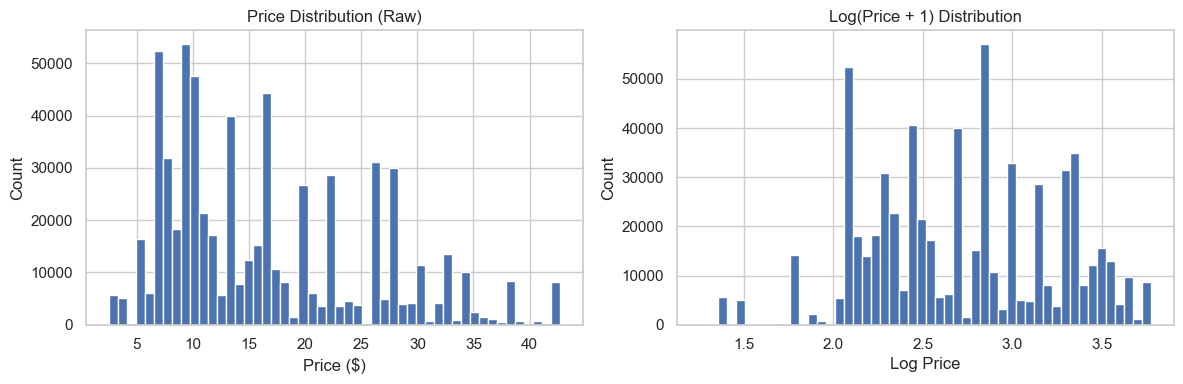

Price Skewness: 0.82
Price Range: $2.50 - $42.75


In [106]:
# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original distribution
axes[0].hist(df['price'].dropna(), bins=50)
axes[0].set_title('Price Distribution (Raw)')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

# Log-transformed distribution
axes[1].hist(np.log1p(df['price'].dropna()), bins=50)
axes[1].set_title('Log(Price + 1) Distribution')
axes[1].set_xlabel('Log Price')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Price Skewness: {df['price'].skew():.2f}")
print(f"Price Range: ${df['price'].min():.2f} - ${df['price'].max():.2f}")

**Observation:** Price is right-skewed (most rides are cheap, a few are expensive). 
The log-transformed version looks more symmetric. Tree-based models handle skew well naturally, 
but this is worth keeping in mind for Linear Regression.

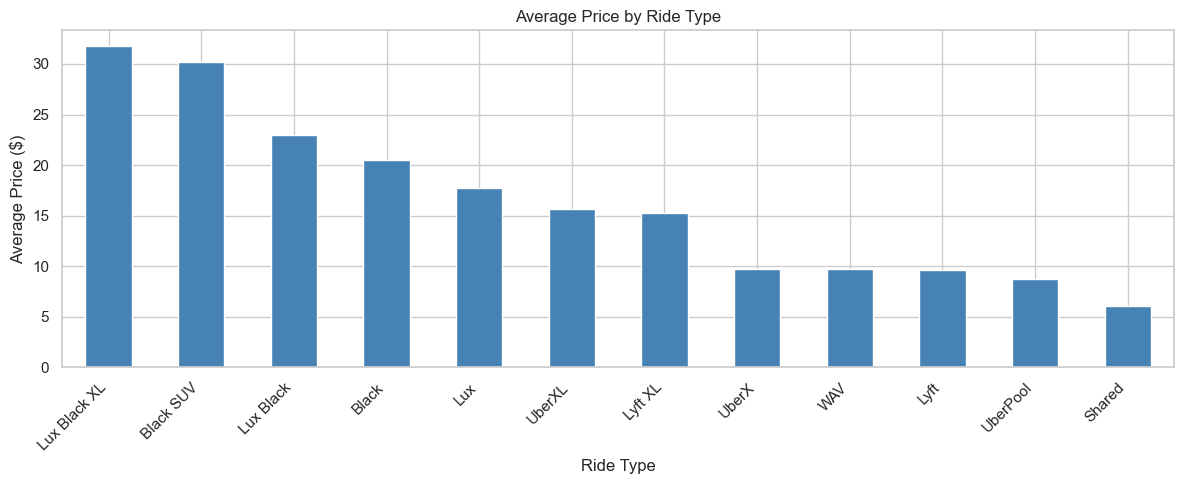

In [101]:
# Average price for each ride type
avg_price_by_cab = df.groupby('name')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
avg_price_by_cab.plot(kind='bar', color='steelblue', edgecolor='white')

plt.title('Average Price by Ride Type')
plt.xlabel('Ride Type')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

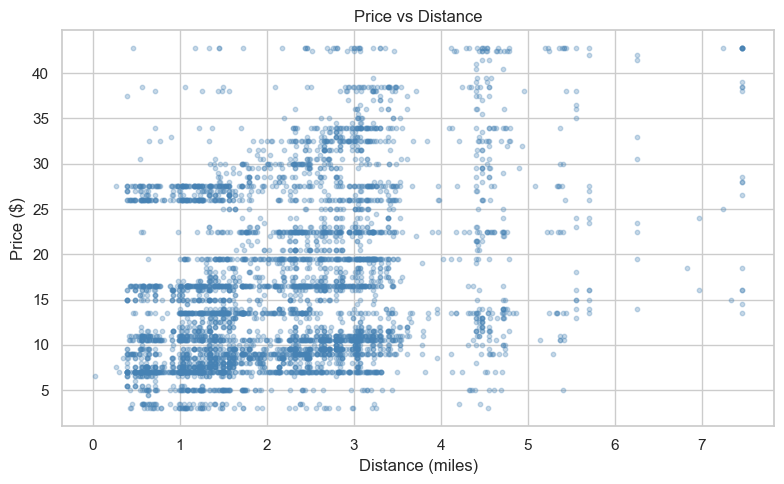

Correlation (distance vs price): 0.344


In [100]:
# Sample a subset of the data for visualization
sample = df[['distance', 'price']].dropna().sample(5000, random_state=RANDOM_SEED)

plt.figure(figsize=(8, 5))
plt.scatter(sample['distance'], sample['price'], alpha=0.3, s=10, color='steelblue')

plt.title('Price vs Distance')
plt.xlabel('Distance (miles)')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

print(f"Correlation (distance vs price): {df['distance'].corr(df['price']):.3f}")

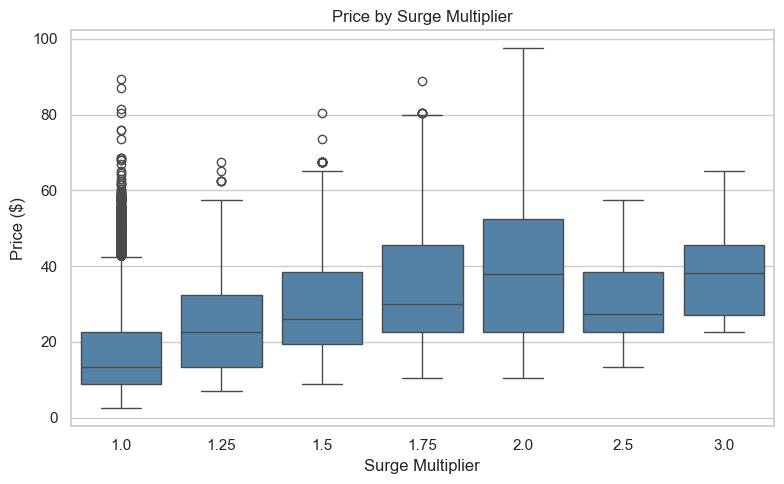

In [52]:
# Analyze the impact of surge multipliers on price distribution
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='surge_multiplier', y='price', color='steelblue')

plt.title('Price by Surge Multiplier')
plt.xlabel('Surge Multiplier')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

**Observation:** Higher surge multipliers are associated with higher ride prices, making surge pricing an important feature for prediction.

In [54]:
numerical_df = df.select_dtypes(include=np.number)
top_correlations = numerical_df.corr()['price'].sort_values(ascending=False)

print("Top Numerical Features Correlated with Price:")
print(top_correlations.head(6)) 

Top Numerical Features Correlated with Price:
price               1.000000
distance            0.345061
surge_multiplier    0.240458
latitude            0.002088
visibility.1        0.001497
visibility          0.001497
Name: price, dtype: float64


## 4. Data Cleaning

In [107]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_summary)

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [56]:
# Drop rows where target variable (price) is missing
df = df.dropna(subset=['price'])
print(f"Rows remaining after dropping null prices: {len(df):,}")

Rows remaining after dropping null prices: 637,976


### 4.2 — Duplicates

In [58]:
print(f"Duplicate rows found: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Total rows after duplicate removal: {len(df):,}")

Duplicate rows found: 0
Total rows after duplicate removal: 637,976


### 4.3 — Outlier Detection & Treatment

In [59]:
# Calculate statistical price bounds using IQR
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"Statistical outliers detected: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}% of dataset)")
print(f"Theoretical price thresholds: ${lower_bound:.2f} to ${upper_bound:.2f}")

Statistical outliers detected: 5,589 (0.88% of dataset)
Theoretical price thresholds: $-11.25 to $42.75


In [60]:
# Cap outliers at the IQR theoretical boundaries to stabilize linear baseline models
df['price'] = df['price'].clip(lower=lower_bound, upper=upper_bound)

print(f"Feature scaled - Price range after capping: ${df['price'].min():.2f} to ${df['price'].max():.2f}")

Feature scaled - Price range after capping: $2.50 to $42.75


## 5. Feature Engineering

Extract time-based features from the timestamp to capture patterns related to ride demand.

In [61]:
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek
df['is_rush_hour'] = 0
df.loc[(df['day_of_week'] < 5) & (df['hour'].between(7, 9)), 'is_rush_hour'] = 1
df.loc[(df['day_of_week'] < 5) & (df['hour'].between(17, 19)), 'is_rush_hour'] = 1
df['is_weekend'] = 0
df.loc[df['day_of_week'] >= 5, 'is_weekend'] = 1
df[['hour', 'day_of_week', 'is_rush_hour', 'is_weekend']].head()

,hour,day_of_week,is_rush_hour,is_weekend
0,9,6,0,1
1,2,1,0,0
2,1,2,0,0
3,4,4,0,0
4,3,3,0,0


## 6. Feature Selection & Categorical Encoding

Select the features for training and remove columns that are not useful for prediction.

Categorical features are encoded using LabelEncoder before training the models.

In [65]:
# List of features we want to keep
features_to_use = [
    'cab_type',
    'name',
    'distance',
    'surge_multiplier',
    'source',
    'destination',
    'hour',
    'day_of_week',
    'is_rush_hour',
    'is_weekend',
    'price'
]

df_model = df[features_to_use].copy()
df_model = df_model.dropna()

print("Final dataset shape:", df_model.shape)
df_model.head()

Final dataset shape: (637976, 11)


,cab_type,name,distance,surge_multiplier,source,destination,hour,day_of_week,is_rush_hour,is_weekend,price
0,Lyft,Shared,0.44,1.0,Haymarket Square,North Station,9,6,0,1,5.0
1,Lyft,Lux,0.44,1.0,Haymarket Square,North Station,2,1,0,0,11.0
2,Lyft,Lyft,0.44,1.0,Haymarket Square,North Station,1,2,0,0,7.0
3,Lyft,Lux Black XL,0.44,1.0,Haymarket Square,North Station,4,4,0,0,26.0
4,Lyft,Lyft XL,0.44,1.0,Haymarket Square,North Station,3,3,0,0,9.0


In [66]:
# Initialize LabelEncoder for categorical variables
categorical_cols = ['cab_type', 'name', 'source', 'destination']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le
    print(f"Encoded {col}: {list(le.classes_)}")

Encoded cab_type: ['Lyft', 'Uber']
Encoded name: ['Black', 'Black SUV', 'Lux', 'Lux Black', 'Lux Black XL', 'Lyft', 'Lyft XL', 'Shared', 'UberPool', 'UberX', 'UberXL', 'WAV']
Encoded source: ['Back Bay', 'Beacon Hill', 'Boston University', 'Fenway', 'Financial District', 'Haymarket Square', 'North End', 'North Station', 'Northeastern University', 'South Station', 'Theatre District', 'West End']
Encoded destination: ['Back Bay', 'Beacon Hill', 'Boston University', 'Fenway', 'Financial District', 'Haymarket Square', 'North End', 'North Station', 'Northeastern University', 'South Station', 'Theatre District', 'West End']


## 7. Train-Test Split

Split the dataset into training and testing sets (80:20).

In [67]:
X = df_model.drop('price', axis=1)
y = df_model['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nFeatures used:", list(X.columns))

X_train shape: (510380, 10)
X_test shape: (127596, 10)

Features used: ['cab_type', 'name', 'distance', 'surge_multiplier', 'source', 'destination', 'hour', 'day_of_week', 'is_rush_hour', 'is_weekend']


## 8. Model Training & Comparison

Train different regression models and compare their performance.

In [74]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2 = r2_score(y_test, y_pred)
    
    return {
        'Model': model_name, 
        'MAE': round(mae, 2), 
        'RMSE': round(rmse, 2), 
        'R2': round(r2, 2)
    }

### 8.1 — Linear Regression (Baseline)

In [75]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_results = evaluate_model(lr_model, X_test, y_test, 'Linear Regression')
print(lr_results)

{'Model': 'Linear Regression', 'MAE': 5.08, 'RMSE': 6.31, 'R2': 0.52}


### 8.2 — Decision Tree

In [76]:
dt_model = DecisionTreeRegressor(max_depth=10, random_state=RANDOM_SEED)
dt_model.fit(X_train, y_train)

dt_results = evaluate_model(dt_model, X_test, y_test, 'Decision Tree')
print(dt_results)

{'Model': 'Decision Tree', 'MAE': 1.1, 'RMSE': 1.65, 'R2': 0.97}


### 8.3 — Random Forest

In [77]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_results = evaluate_model(rf_model, X_test, y_test, 'Random Forest')
print(rf_results)

{'Model': 'Random Forest', 'MAE': 1.12, 'RMSE': 1.75, 'R2': 0.96}


### 8.4 — XGBoost

In [78]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=RANDOM_SEED,
    verbosity=0
)
xgb_model.fit(X_train, y_train)

xgb_results = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')
print(xgb_results)

{'Model': 'XGBoost', 'MAE': 1.08, 'RMSE': 1.61, 'R2': 0.97}


## MODEL COMPARISON

In [80]:
results = pd.DataFrame([lr_results, dt_results, rf_results, xgb_results])
results = results.sort_values('R2', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

            Model  MAE  RMSE   R2
    Decision Tree 1.10  1.65 0.97
          XGBoost 1.08  1.61 0.97
    Random Forest 1.12  1.75 0.96
Linear Regression 5.08  6.31 0.52


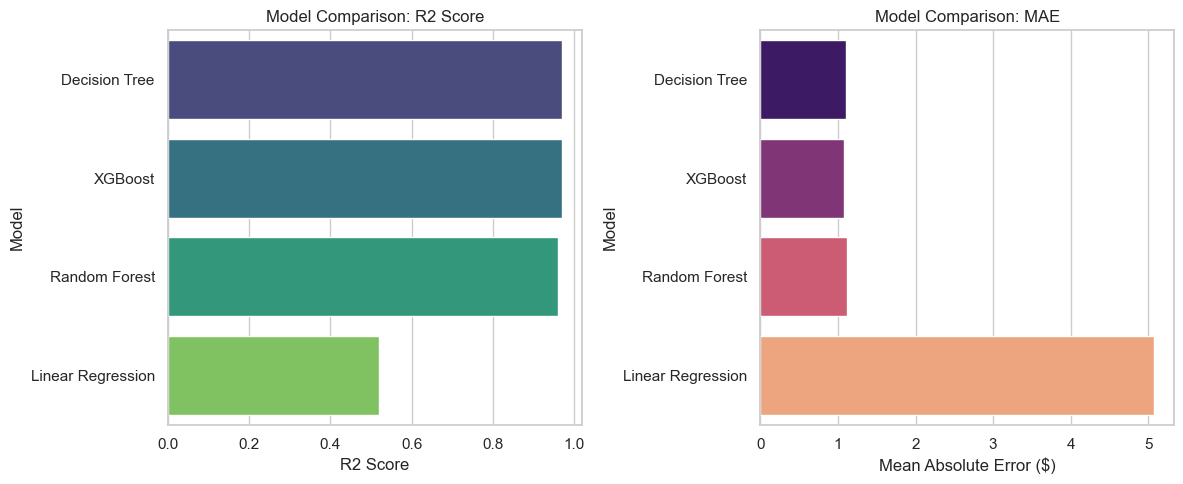

In [99]:
# Compare model performance
plt.figure(figsize=(12, 5))

# R² Score
plt.subplot(1, 2, 1)
sns.barplot(data=results, x='R2', y='Model', palette='viridis')
plt.title('Model Comparison: R2 Score')
plt.xlabel('R2 Score')

# MAE (Lower is better)
plt.subplot(1, 2, 2)
sns.barplot(data=results, x='MAE', y='Model', palette='magma')
plt.title('Model Comparison: MAE')
plt.xlabel('Mean Absolute Error ($)')

plt.tight_layout()
plt.show()

**Observation:** Tree-based models performed much better than Linear Regression, indicating that the pricing data contains non-linear relationships.

## 9. Hyperparameter Tuning


In [98]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_base = XGBRegressor(random_state=RANDOM_SEED, verbosity=0)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring='r2',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)
print("Best parameters:")
print(random_search.best_params_)
print("Best CV R2 score:", round(random_search.best_score_, 4))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters:
{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV R2 score: 0.9699


In [97]:
best_model = random_search.best_estimator_

tuned_results = evaluate_model(best_model, X_test, y_test, "XGBoost (Tuned)")

print(f"MAE : {tuned_results['MAE']:.2f}")
print(f"RMSE: {tuned_results['RMSE']:.2f}")
print(f"R²  : {tuned_results['R2']:.2f}")

MAE : 1.02
RMSE: 1.55
R²  : 0.97


## Actual vs Predicted

Plot the predicted values against the actual values.

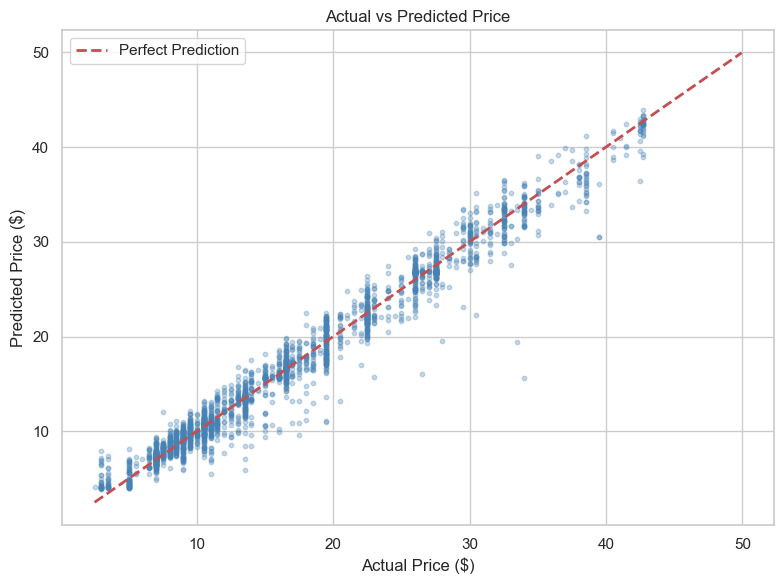

In [95]:
# Predict on test set
y_pred = best_model.predict(X_test)

sample_idx = np.random.choice(len(y_test), size=3000, replace=False)

plt.figure(figsize=(8, 6))
plt.scatter(
    np.array(y_test)[sample_idx],
    y_pred[sample_idx],
    alpha=0.3,
    s=10,
    color='steelblue'
)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.title('Actual vs Predicted Price')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Feature Importance

Analyzing which features contribute the most predictive power to our final tuned XGBoost model.

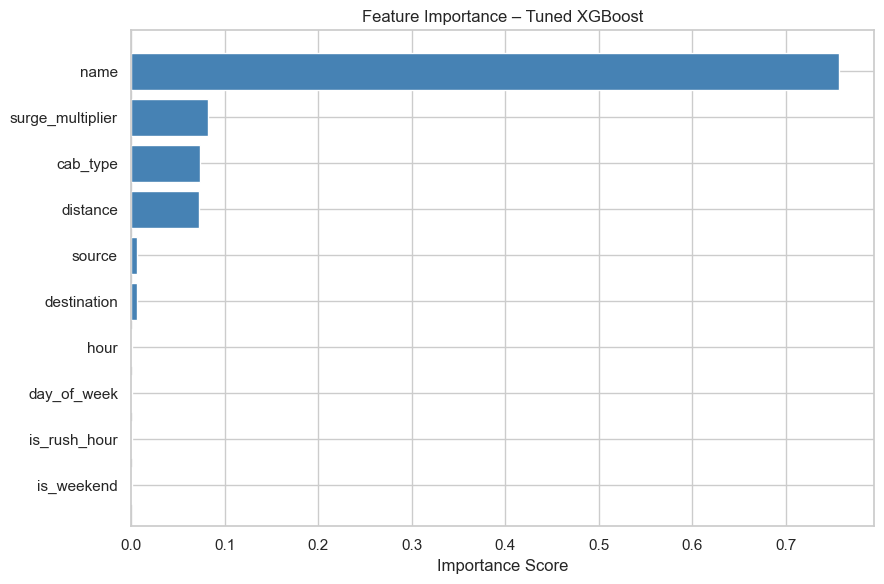

In [88]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue', edgecolor='white')

plt.title('Feature Importance – Tuned XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [93]:
import joblib

# Save the final tuned XGBoost model to a file
joblib.dump(best_model, 'xgboost_dynamic_pricing_model.pkl')
print("Model successfully saved as xgboost_dynamic_pricing_model.pkl")

Model successfully saved as xgboost_dynamic_pricing_model.pkl
